<a href="https://colab.research.google.com/github/Tanxinru05/mem-gnn-rnn-continuous-prediction/blob/main/CNN%2BBILSTM%2BAttn__Beijing_PM2_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#pollution data
# preprocess_sequential.py (For CNN+LSTM+Attn models)

import pandas as pd
import numpy as np
import os
from sklearn.preprocessing import MinMaxScaler

def create_sequential_data(raw_data_path='pollution.csv', output_dir='./processed_sequential_minmax/', sequence_length=14):
    """
    Loads raw data, creates daily features, and then transforms them into
    input sequences (X) and targets (y) for sequence models.
    """
    print(f"--- Starting Sequential Pre-processing for '{raw_data_path}' ---")

    # 1. Load and create daily features (This part is similar to before)
    try:
        df = pd.read_csv(raw_data_path)
        df['Datetime'] = pd.to_datetime(df['date'], dayfirst=True)
        df.set_index('Datetime', inplace=True)
    except Exception as e:
        print(f"ERROR: Could not load or process '{raw_data_path}'. Details: {e}")
        return

    daily_df = df.resample('D').agg({
        'pollution': 'mean',
        'dew': 'mean',
        'temp': 'mean',
        'press': 'mean',
        'wnd_spd': 'mean',
        'snow': 'sum',
        'rain': 'sum'
    })

    # Handle missing values robustly
    daily_df.ffill(inplace=True)
    daily_df.fillna(0, inplace=True)

    print("Successfully created daily aggregated features.")

    # 2. Create the target variable and scale features
    # The label is the next day's pollution. We shift the pollution column.
    daily_df['label'] = daily_df['pollution'].shift(-1)

    # Drop the last row since it will have a NaN label
    daily_df.dropna(inplace=True)

    feature_columns = [col for col in daily_df.columns if col != 'label']
    features = daily_df[feature_columns].values

    scaler = MinMaxScaler()
    features_scaled = scaler.fit_transform(features)

    # We use the scaled features for our sequences (X) and the unscaled label for our target (y)
    labels = daily_df['label'].values

    # 3. Create sequences using a sliding window
    X, y = [], []
    for i in range(len(features_scaled) - sequence_length):
        # The sequence of features [i to i+sequence_length-1]
        X.append(features_scaled[i:(i + sequence_length)])
        # The target is the label at the end of the sequence
        y.append(labels[i + sequence_length - 1])

    X, y = np.array(X), np.array(y)

    print(f"Created {len(X)} sequences of length {sequence_length}.")
    print(f"Shape of X: {X.shape}") # (num_samples, sequence_length, num_features)
    print(f"Shape of y: {y.shape}") # (num_samples,)

    # 4. Save the final sequence arrays
    os.makedirs(output_dir, exist_ok=True)
    X_OUT_PATH = os.path.join(output_dir, 'X_data.npy')
    Y_OUT_PATH = os.path.join(output_dir, 'y_data.npy')

    np.save(X_OUT_PATH, X)
    np.save(Y_OUT_PATH, y)

    print("\n--- Sequential Pre-processing Complete! ---")
    print(f"Sequence data saved in '{output_dir}' directory.")


if __name__ == "__main__":
    create_sequential_data(sequence_length=14)

--- Starting Sequential Pre-processing for 'pollution.csv' ---
Successfully created daily aggregated features.
Created 1810 sequences of length 14.
Shape of X: (1810, 14, 7)
Shape of y: (1810,)

--- Sequential Pre-processing Complete! ---
Sequence data saved in './processed_sequential_minmax/' directory.


[I 2025-06-22 17:45:25,964] A new study created in memory with name: no-name-3752119c-bab6-4dbb-ab3b-6aced4dae2ab


Using device: cpu
Loading pre-processed sequential data from: ./processed_sequential_minmax/
Sequential data loaded successfully.

--- Running Bayesian Optimization ---


[I 2025-06-22 17:45:27,629] Trial 0 finished with value: 0.0211191772866775 and parameters: {'cnn_out_channels': 52, 'kernel_size': 5, 'lstm_hidden_dim': 48, 'lr': 0.0008853804506791349, 'dropout': 0.22314107355198365, 'batch_size': 32}. Best is trial 0 with value: 0.0211191772866775.
[I 2025-06-22 17:45:29,828] Trial 1 finished with value: 0.012795502593850388 and parameters: {'cnn_out_channels': 53, 'kernel_size': 2, 'lstm_hidden_dim': 70, 'lr': 0.009325470353969998, 'dropout': 0.3585827521423607, 'batch_size': 32}. Best is trial 1 with value: 0.012795502593850388.
[I 2025-06-22 17:45:31,578] Trial 2 finished with value: 0.019789958756197903 and parameters: {'cnn_out_channels': 43, 'kernel_size': 5, 'lstm_hidden_dim': 53, 'lr': 0.001091024632058081, 'dropout': 0.10677980913020808, 'batch_size': 32}. Best is trial 1 with value: 0.012795502593850388.
[I 2025-06-22 17:45:34,116] Trial 3 finished with value: 0.018131171870562766 and parameters: {'cnn_out_channels': 53, 'kernel_size': 3, 


Best trial found: Loss = 0.0128
Best parameters: {'cnn_out_channels': 53, 'kernel_size': 2, 'lstm_hidden_dim': 70, 'lr': 0.009325470353969998, 'dropout': 0.3585827521423607, 'batch_size': 32}

--- Starting Final Model Training ---
Epoch 005: Train Loss = 0.014805 | Val Loss = 0.014771
Epoch 010: Train Loss = 0.015546 | Val Loss = 0.015513
Epoch 015: Train Loss = 0.014062 | Val Loss = 0.014751
Epoch 020: Train Loss = 0.014057 | Val Loss = 0.014373
Epoch 025: Train Loss = 0.013630 | Val Loss = 0.014555
Early stopping triggered at epoch 29.


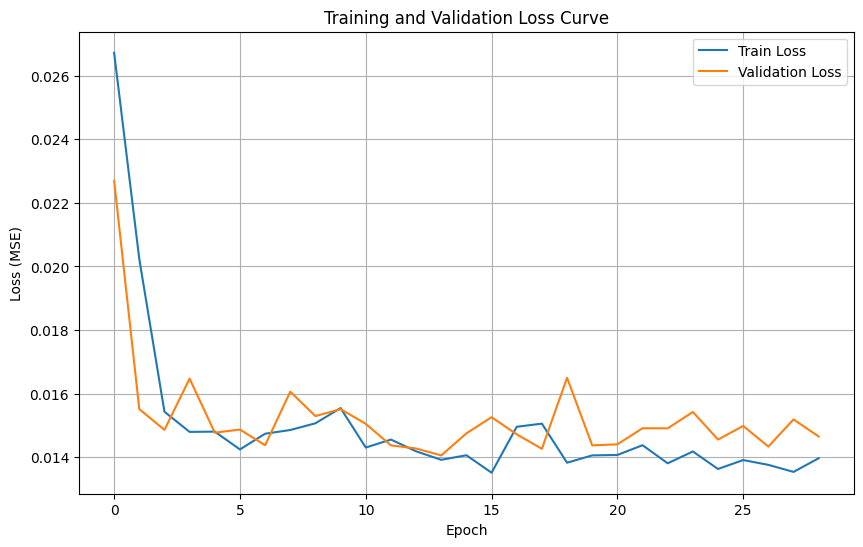


--- Final Test Metrics (Pollution Forecast) ---
RMSE: 57.4569
MAE: 42.6141
R2: 0.2145


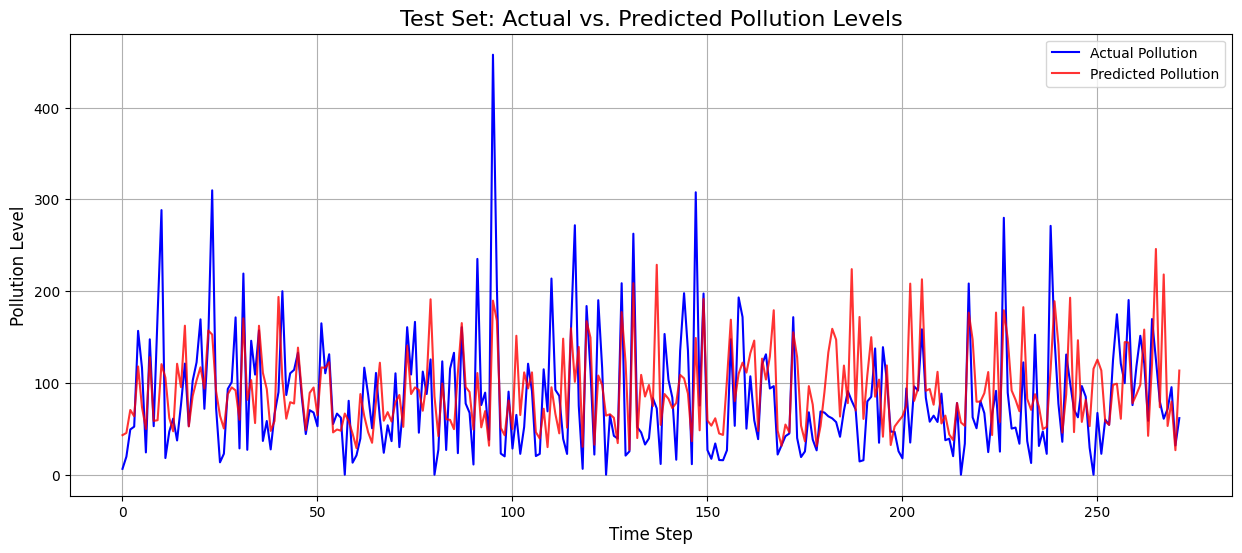

In [ ]:
# module_cnn_bilstm_attn.py (CNN+BiLSTM+Attention Architecture)

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import optuna
import warnings
from time import time
import os

# ----- Setup -----
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ======================================================================================
# PART 1: MODEL ARCHITECTURE (COMPLETELY NEW)
# ======================================================================================
class Attention(nn.Module):
    """ Simple Bahdanau Attention """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Parameter(torch.rand(hidden_dim))
        self.v.data.normal_(mean=0, std=1./np.sqrt(self.v.size(0)))

    def forward(self, hidden_states):
        # hidden_states: (batch_size, seq_len, hidden_dim)
        energy = torch.tanh(self.attn(hidden_states))
        energy = energy.transpose(1, 2) # (batch, hidden_dim, seq_len)
        v = self.v.repeat(hidden_states.size(0), 1).unsqueeze(1) # (batch, 1, hidden_dim)
        energy = torch.bmm(v, energy) # (batch, 1, seq_len)
        attn_weights = F.softmax(energy.squeeze(1), dim=1) # (batch, seq_len)
        context_vector = torch.bmm(attn_weights.unsqueeze(1), hidden_states).squeeze(1)
        return context_vector, attn_weights

class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, input_dim, cnn_out_channels, kernel_size, lstm_hidden_dim, dropout):
        super().__init__()
        # 1. CNN Layer
        self.conv1d = nn.Conv1d(in_channels=input_dim, out_channels=cnn_out_channels,
                                kernel_size=kernel_size, padding='same')
        self.relu = nn.ReLU()

        # 2. BiLSTM Layer
        self.lstm = nn.LSTM(cnn_out_channels, lstm_hidden_dim, batch_first=True, bidirectional=True)

        # 3. Attention Layer
        self.attention = Attention(lstm_hidden_dim * 2) # *2 for bidirectional

        # 4. Regression Head
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden_dim * 2, 1)

    def forward(self, x):
        # Input x: (batch_size, seq_len, num_features)
        x = x.permute(0, 2, 1) # (batch_size, num_features, seq_len) for Conv1D

        # Pass through CNN
        cnn_out = self.relu(self.conv1d(x))
        cnn_out = cnn_out.permute(0, 2, 1) # (batch_size, seq_len, cnn_out_channels) for LSTM

        # Pass through BiLSTM
        lstm_out, _ = self.lstm(cnn_out)

        # Pass through Attention
        context_vector, attn_weights = self.attention(lstm_out)

        # Get final prediction
        out = self.dropout(context_vector)
        return self.fc(out)

# ======================================================================================
# PART 2: MAIN WORKFLOW (ADAPTED FOR SEQUENTIAL DATA)
# ======================================================================================
def load_processed_data(data_dir='./processed_sequential_minmax/'):
    print(f"Loading pre-processed sequential data from: {data_dir}")
    try:
        X = np.load(os.path.join(data_dir, 'X_data.npy'))
        y = np.load(os.path.join(data_dir, 'y_data.npy'))
        # Add a dimension to y for the scaler
        y = y.reshape(-1, 1)
    except FileNotFoundError:
        print(f"ERROR: Pre-processed files not found. Please run 'preprocess_sequential.py' first.")
        return None, None
    print("Sequential data loaded successfully.")
    return X, y

def objective(trial, X_tensor, y_tensor):
    """ Optuna objective function for the new architecture. """
    try:
        # Hyperparameters to tune
        params = {
            'cnn_out_channels': trial.suggest_int('cnn_out_channels', 16, 64),
            'kernel_size': trial.suggest_categorical('kernel_size', [2, 3, 5]),
            'lstm_hidden_dim': trial.suggest_int('lstm_hidden_dim', 32, 128),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'dropout': trial.suggest_float('dropout', 0.1, 0.5),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64])
        }

        # Create dataset and loaders
        full_dataset = TensorDataset(X_tensor, y_tensor)
        train_size = int(0.7 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
        train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=params['batch_size'])

        # Instantiate model
        input_dim = X_tensor.shape[2]
        model = CNN_BiLSTM_Attention(
            input_dim=input_dim,
            cnn_out_channels=params['cnn_out_channels'],
            kernel_size=params['kernel_size'],
            lstm_hidden_dim=params['lstm_hidden_dim'],
            dropout=params['dropout']
        ).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
        criterion = nn.MSELoss()

        # Short training loop for Optuna
        model.train()
        for epoch in range(3):
            for x_b, y_b in train_loader:
                x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
                optimizer.zero_grad()
                pred = model(x_b)
                loss = criterion(pred, y_b)
                loss.backward()
                optimizer.step()

        # Evaluate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
                pred = model(x_b)
                val_loss += criterion(pred, y_b).item()

        return val_loss / len(val_loader)

    except Exception as e:
        print(f"Trial failed with error: {e}. Pruning.")
        return float('inf') # Return a large value if trial fails

# Function to plot the loss curve (ADDED)
def plot_loss_curve(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()


def train_final_model(model, train_loader, val_loader, params, epochs=100, patience=15):
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.MSELoss()
    best_val_loss, patience_counter = float('inf'), 0
    train_loss_history, val_loss_history = [], []
    print("\n--- Starting Final Model Training ---")
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            pred = model(x_b)
            loss = criterion(pred, y_b)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
                pred = model(x_b)
                epoch_val_loss += criterion(pred, y_b).item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_val_loss = epoch_val_loss / len(val_loader)
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_val_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:03d}: Train Loss = {avg_train_loss:.6f} | Val Loss = {avg_val_loss:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss, patience_counter = avg_val_loss, 0
            torch.save(model.state_dict(), 'best_cnn_lstm_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}.")
                break

    model.load_state_dict(torch.load('best_cnn_lstm_model.pth'))
    return model, train_loss_history, val_loss_history

def evaluate_and_plot(model, test_loader, target_scaler):
    model.eval()
    all_preds, all_truths = [], []
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            pred = model(x_b)
            all_preds.append(pred.cpu())
            all_truths.append(y_b.cpu())

    preds_scaled = torch.cat(all_preds).numpy()
    truths_scaled = torch.cat(all_truths).numpy()

    # Inverse transform to get original scale
    preds = target_scaler.inverse_transform(preds_scaled)
    truths = target_scaler.inverse_transform(truths_scaled)

    metrics = {
        'RMSE': np.sqrt(mean_squared_error(truths, preds)),
        'MAE': mean_absolute_error(truths, preds),
        'R2': r2_score(truths, preds)
    }

    print("\n--- Final Test Metrics (Pollution Forecast) ---")
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    plt.figure(figsize=(15, 6))
    plt.plot(truths.flatten(), label='Actual Pollution', color='blue')
    plt.plot(preds.flatten(), label='Predicted Pollution', color='red', alpha=0.8)
    plt.title("Test Set: Actual vs. Predicted Pollution Levels", fontsize=16)
    plt.xlabel("Time Step", fontsize=12)
    plt.ylabel("Pollution Level", fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()
    return metrics

if __name__ == "__main__":
    X, y = load_processed_data()

    if X is not None:
        # Scale the target variable 'y'
        y_scaler = MinMaxScaler()
        y_scaled = y_scaler.fit_transform(y)

        X_tensor = torch.from_numpy(X).float()
        y_tensor = torch.from_numpy(y_scaled).float()

        print("\n--- Running Bayesian Optimization ---")
        study = optuna.create_study(direction='minimize')
        study.optimize(lambda trial: objective(trial, X_tensor, y_tensor), n_trials=30)
        best_params = study.best_params
        print(f"\nBest trial found: Loss = {study.best_value:.4f}\nBest parameters: {best_params}")

        # Create final datasets and loaders
        full_dataset = TensorDataset(X_tensor, y_tensor)
        train_val_size = int(0.85 * len(full_dataset)); test_size = len(full_dataset) - train_val_size
        train_dataset, test_dataset = random_split(full_dataset, [train_val_size, test_size])
        train_size = int(0.8 * len(train_dataset)); val_size = len(train_dataset) - train_size
        train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

        train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'])
        test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'])

        # Initialize and train the final model
        final_model = CNN_BiLSTM_Attention(
            input_dim=X.shape[2],
            cnn_out_channels=best_params['cnn_out_channels'],
            kernel_size=best_params['kernel_size'],
            lstm_hidden_dim=best_params['lstm_hidden_dim'],
            dropout=best_params['dropout']
        ).to(DEVICE)

        final_model, train_losses, val_losses = train_final_model(final_model, train_loader, val_loader, best_params)

        # Plot loss and evaluate
        plot_loss_curve(train_losses, val_losses)
        evaluate_and_plot(final_model, test_loader, y_scaler)

[I 2025-06-22 17:58:59,117] A new study created in memory with name: no-name-d606b20c-a89e-46b3-bae9-44e11ed2c39a


Using device: cpu
Loading pre-processed sequential data from: ./processed_sequential/
Sequential data loaded successfully.

--- Running Bayesian Optimization ---


[I 2025-06-22 17:59:01,267] Trial 0 finished with value: 0.9952206734348746 and parameters: {'cnn_out_channels': 43, 'kernel_size': 3, 'lstm_hidden_dim': 48, 'lr': 0.00012294865460168322, 'dropout': 0.39223710401813405, 'batch_size': 32}. Best is trial 0 with value: 0.9952206734348746.
[I 2025-06-22 17:59:04,196] Trial 1 finished with value: 0.6758168107933469 and parameters: {'cnn_out_channels': 51, 'kernel_size': 3, 'lstm_hidden_dim': 120, 'lr': 0.0036546419530568393, 'dropout': 0.38319853215491995, 'batch_size': 64}. Best is trial 1 with value: 0.6758168107933469.
[I 2025-06-22 17:59:05,678] Trial 2 finished with value: 0.9119604097472297 and parameters: {'cnn_out_channels': 58, 'kernel_size': 5, 'lstm_hidden_dim': 64, 'lr': 0.0011939538421760466, 'dropout': 0.27834558894693195, 'batch_size': 64}. Best is trial 1 with value: 0.6758168107933469.
[I 2025-06-22 17:59:08,012] Trial 3 finished with value: 0.662524493301616 and parameters: {'cnn_out_channels': 51, 'kernel_size': 2, 'lstm_


Best trial found: Loss = 0.5952
Best parameters: {'cnn_out_channels': 58, 'kernel_size': 2, 'lstm_hidden_dim': 32, 'lr': 0.005293316915089569, 'dropout': 0.33654888878744416, 'batch_size': 64}

--- Starting Final Model Training ---
Epoch 005: Train Loss = 0.613078 | Val Loss = 0.559616
Epoch 010: Train Loss = 0.594027 | Val Loss = 0.560464
Epoch 015: Train Loss = 0.540566 | Val Loss = 0.544528
Epoch 020: Train Loss = 0.541827 | Val Loss = 0.561677
Epoch 025: Train Loss = 0.479692 | Val Loss = 0.627460
Epoch 030: Train Loss = 0.405950 | Val Loss = 0.619833
Early stopping triggered at epoch 30.


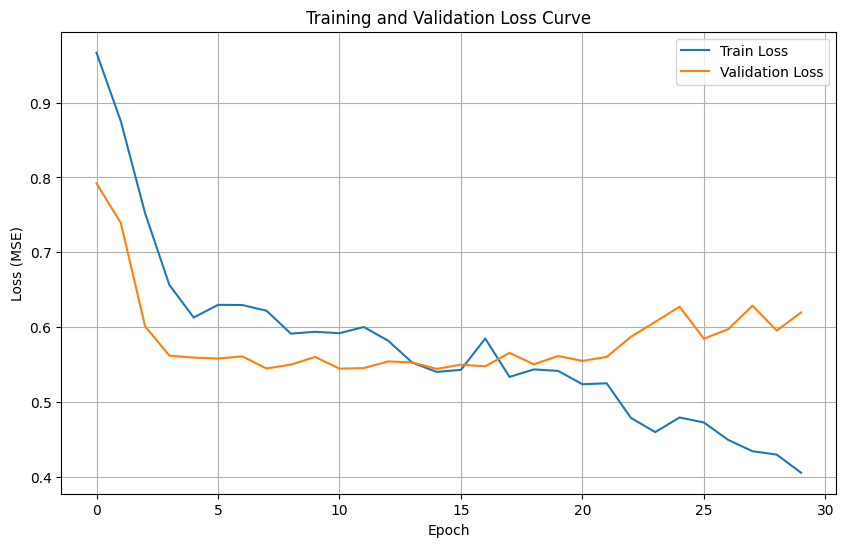


--- Final Test Metrics (Pollution Forecast) ---
RMSE: 65.0767
MAE: 47.2890
R2: 0.5041


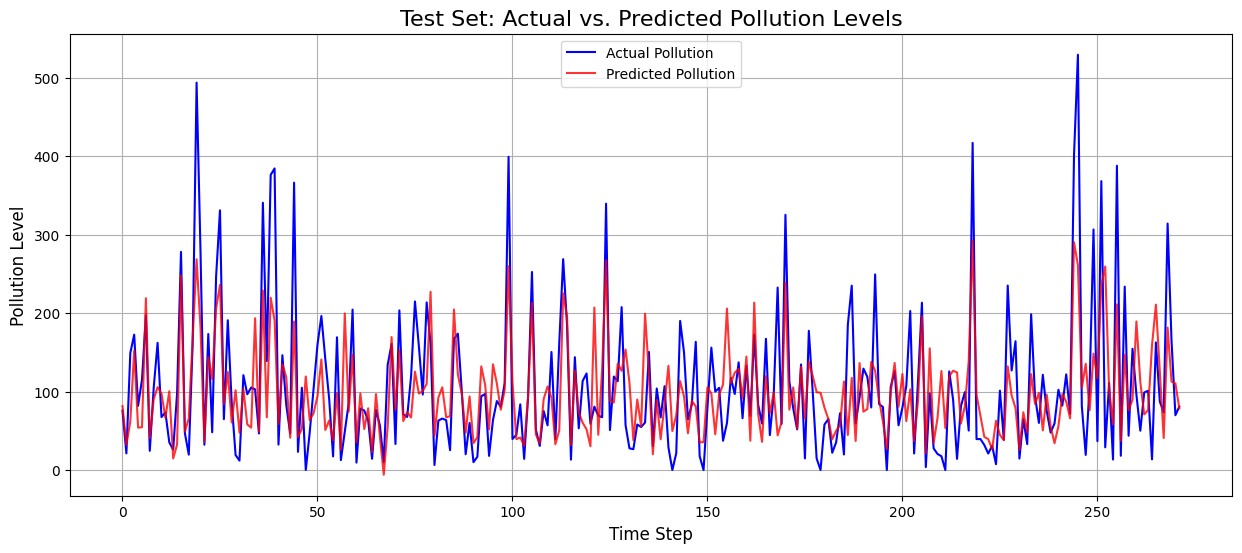

In [ ]:
# module_cnn_bilstm_attn.py (CNN+BiLSTM+Attention Architecture)

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import optuna
import warnings
from time import time
import os

# ----- Setup -----
warnings.filterwarnings('ignore')
torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ======================================================================================
# PART 1: MODEL ARCHITECTURE (COMPLETELY NEW)
# ======================================================================================
class Attention(nn.Module):
    """ Simple Bahdanau Attention """
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Parameter(torch.rand(hidden_dim))
        self.v.data.normal_(mean=0, std=1./np.sqrt(self.v.size(0)))

    def forward(self, hidden_states):
        # hidden_states: (batch_size, seq_len, hidden_dim)
        energy = torch.tanh(self.attn(hidden_states))
        energy = energy.transpose(1, 2) # (batch, hidden_dim, seq_len)
        v = self.v.repeat(hidden_states.size(0), 1).unsqueeze(1) # (batch, 1, hidden_dim)
        energy = torch.bmm(v, energy) # (batch, 1, seq_len)
        attn_weights = F.softmax(energy.squeeze(1), dim=1) # (batch, seq_len)
        context_vector = torch.bmm(attn_weights.unsqueeze(1), hidden_states).squeeze(1)
        return context_vector, attn_weights

class CNN_BiLSTM_Attention(nn.Module):
    def __init__(self, input_dim, cnn_out_channels, kernel_size, lstm_hidden_dim, dropout):
        super().__init__()
        # 1. CNN Layer
        self.conv1d = nn.Conv1d(in_channels=input_dim, out_channels=cnn_out_channels,
                                kernel_size=kernel_size, padding='same')
        self.relu = nn.ReLU()

        # 2. BiLSTM Layer
        self.lstm = nn.LSTM(cnn_out_channels, lstm_hidden_dim, batch_first=True, bidirectional=True)

        # 3. Attention Layer
        self.attention = Attention(lstm_hidden_dim * 2) # *2 for bidirectional

        # 4. Regression Head
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden_dim * 2, 1)

    def forward(self, x):
        # Input x: (batch_size, seq_len, num_features)
        x = x.permute(0, 2, 1) # (batch_size, num_features, seq_len) for Conv1D

        # Pass through CNN
        cnn_out = self.relu(self.conv1d(x))
        cnn_out = cnn_out.permute(0, 2, 1) # (batch_size, seq_len, cnn_out_channels) for LSTM

        # Pass through BiLSTM
        lstm_out, _ = self.lstm(cnn_out)

        # Pass through Attention
        context_vector, attn_weights = self.attention(lstm_out)

        # Get final prediction
        out = self.dropout(context_vector)
        return self.fc(out)

# ======================================================================================
# PART 2: MAIN WORKFLOW (ADAPTED FOR SEQUENTIAL DATA)
# ======================================================================================
def load_processed_data(data_dir='./processed_sequential/'):
    print(f"Loading pre-processed sequential data from: {data_dir}")
    try:
        X = np.load(os.path.join(data_dir, 'X_data.npy'))
        y = np.load(os.path.join(data_dir, 'y_data.npy'))
        # Add a dimension to y for the scaler
        y = y.reshape(-1, 1)
    except FileNotFoundError:
        print(f"ERROR: Pre-processed files not found. Please run 'preprocess_sequential.py' first.")
        return None, None
    print("Sequential data loaded successfully.")
    return X, y

def objective(trial, X_tensor, y_tensor):
    """ Optuna objective function for the new architecture. """
    try:
        # Hyperparameters to tune
        params = {
            'cnn_out_channels': trial.suggest_int('cnn_out_channels', 16, 64),
            'kernel_size': trial.suggest_categorical('kernel_size', [2, 3, 5]),
            'lstm_hidden_dim': trial.suggest_int('lstm_hidden_dim', 32, 128),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'dropout': trial.suggest_float('dropout', 0.1, 0.5),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64])
        }

        # Create dataset and loaders
        full_dataset = TensorDataset(X_tensor, y_tensor)
        train_size = int(0.7 * len(full_dataset))
        val_size = len(full_dataset) - train_size
        train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])
        train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=params['batch_size'])

        # Instantiate model
        input_dim = X_tensor.shape[2]
        model = CNN_BiLSTM_Attention(
            input_dim=input_dim,
            cnn_out_channels=params['cnn_out_channels'],
            kernel_size=params['kernel_size'],
            lstm_hidden_dim=params['lstm_hidden_dim'],
            dropout=params['dropout']
        ).to(DEVICE)

        optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
        criterion = nn.MSELoss()

        # Short training loop for Optuna
        model.train()
        for epoch in range(3):
            for x_b, y_b in train_loader:
                x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
                optimizer.zero_grad()
                pred = model(x_b)
                loss = criterion(pred, y_b)
                loss.backward()
                optimizer.step()

        # Evaluate
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
                pred = model(x_b)
                val_loss += criterion(pred, y_b).item()

        return val_loss / len(val_loader)

    except Exception as e:
        print(f"Trial failed with error: {e}. Pruning.")
        return float('inf') # Return a large value if trial fails

# Function to plot the loss curve (ADDED)
def plot_loss_curve(train_losses, val_losses):
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Loss Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()


def train_final_model(model, train_loader, val_loader, params, epochs=100, patience=15):
    optimizer = torch.optim.Adam(model.parameters(), lr=params['lr'])
    criterion = nn.MSELoss()
    best_val_loss, patience_counter = float('inf'), 0
    train_loss_history, val_loss_history = [], []
    print("\n--- Starting Final Model Training ---")
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for x_b, y_b in train_loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            optimizer.zero_grad()
            pred = model(x_b)
            loss = criterion(pred, y_b)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for x_b, y_b in val_loader:
                x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
                pred = model(x_b)
                epoch_val_loss += criterion(pred, y_b).item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        avg_val_loss = epoch_val_loss / len(val_loader)
        train_loss_history.append(avg_train_loss)
        val_loss_history.append(avg_val_loss)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:03d}: Train Loss = {avg_train_loss:.6f} | Val Loss = {avg_val_loss:.6f}")

        if avg_val_loss < best_val_loss:
            best_val_loss, patience_counter = avg_val_loss, 0
            torch.save(model.state_dict(), 'best_cnn_lstm_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}.")
                break

    model.load_state_dict(torch.load('best_cnn_lstm_model.pth'))
    return model, train_loss_history, val_loss_history

def evaluate_and_plot(model, test_loader, target_scaler):
    model.eval()
    all_preds, all_truths = [], []
    with torch.no_grad():
        for x_b, y_b in test_loader:
            x_b, y_b = x_b.to(DEVICE), y_b.to(DEVICE)
            pred = model(x_b)
            all_preds.append(pred.cpu())
            all_truths.append(y_b.cpu())

    preds_scaled = torch.cat(all_preds).numpy()
    truths_scaled = torch.cat(all_truths).numpy()

    # Inverse transform to get original scale
    preds = target_scaler.inverse_transform(preds_scaled)
    truths = target_scaler.inverse_transform(truths_scaled)

    metrics = {
        'RMSE': np.sqrt(mean_squared_error(truths, preds)),
        'MAE': mean_absolute_error(truths, preds),
        'R2': r2_score(truths, preds)
    }

    print("\n--- Final Test Metrics (Pollution Forecast) ---")
    for name, value in metrics.items():
        print(f"{name}: {value:.4f}")

    plt.figure(figsize=(15, 6))
    plt.plot(truths.flatten(), label='Actual Pollution', color='blue')
    plt.plot(preds.flatten(), label='Predicted Pollution', color='red', alpha=0.8)
    plt.title("Test Set: Actual vs. Predicted Pollution Levels", fontsize=16)
    plt.xlabel("Time Step", fontsize=12)
    plt.ylabel("Pollution Level", fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()
    return metrics

if __name__ == "__main__":
    X, y = load_processed_data()

    if X is not None:
        # Scale the target variable 'y'
        y_scaler = StandardScaler()
        y_scaled = y_scaler.fit_transform(y)

        X_tensor = torch.from_numpy(X).float()
        y_tensor = torch.from_numpy(y_scaled).float()

        print("\n--- Running Bayesian Optimization ---")
        study = optuna.create_study(direction='minimize')
        study.optimize(lambda trial: objective(trial, X_tensor, y_tensor), n_trials=30)
        best_params = study.best_params
        print(f"\nBest trial found: Loss = {study.best_value:.4f}\nBest parameters: {best_params}")

        # Create final datasets and loaders
        full_dataset = TensorDataset(X_tensor, y_tensor)
        train_val_size = int(0.85 * len(full_dataset)); test_size = len(full_dataset) - train_val_size
        train_dataset, test_dataset = random_split(full_dataset, [train_val_size, test_size])
        train_size = int(0.8 * len(train_dataset)); val_size = len(train_dataset) - train_size
        train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

        train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'])
        test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'])

        # Initialize and train the final model
        final_model = CNN_BiLSTM_Attention(
            input_dim=X.shape[2],
            cnn_out_channels=best_params['cnn_out_channels'],
            kernel_size=best_params['kernel_size'],
            lstm_hidden_dim=best_params['lstm_hidden_dim'],
            dropout=best_params['dropout']
        ).to(DEVICE)

        final_model, train_losses, val_losses = train_final_model(final_model, train_loader, val_loader, best_params)

        # Plot loss and evaluate
        plot_loss_curve(train_losses, val_losses)
        evaluate_and_plot(final_model, test_loader, y_scaler)